In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
np.random.seed(42)

In [11]:
data={
    "Customer_ID":np.random.randint(1, 100000, size=100000),
    "Age":np.random.randint(18, 65, size=100000),
    "Gender":np.random.choice(["Male","Female"], size=100000),
    "Tenure":np.random.randint(1, 10, size=100000),
    "Balance":np.random.randint(1000, 100000, size=100000),
    "CreditScore":np.random.randint(300, 850, size=100000),
    "Estimatedsalary":np.random.randint(20000, 100000, size=100000),
    "Numofproducts":np.random.randint(1, 5, size=100000),
    "IsActivateMember":np.random.choice([0,1], size=100000),
    "Churn":np.random.choice([0,1], size=100000)
}

In [12]:
df=pd.DataFrame(data)

In [13]:
df

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,Estimatedsalary,Numofproducts,IsActivateMember,Churn
0,15796,18,Male,7,62698,782,38443,2,1,1
1,861,44,Female,7,83347,551,20493,3,1,0
2,76821,31,Male,8,27595,792,78520,4,0,0
3,54887,58,Male,2,36566,504,76259,3,1,0
4,6266,26,Female,2,25841,651,44546,4,0,0
...,...,...,...,...,...,...,...,...,...,...
99995,57886,57,Male,1,69477,812,41576,3,0,0
99996,50578,42,Male,5,48562,813,24127,1,1,1
99997,87557,19,Female,5,64924,623,45439,1,1,1
99998,12118,60,Male,6,7807,823,51528,1,0,1


In [14]:
pip install faker

In [16]:
from faker import Faker
fake=Faker()
df["name"]=[fake.name() for _ in range(len(df))]
df

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,Estimatedsalary,Numofproducts,IsActivateMember,Churn,name
0,15796,18,Male,7,62698,782,38443,2,1,1,Kelly Medina
1,861,44,Female,7,83347,551,20493,3,1,0,Courtney Norman
2,76821,31,Male,8,27595,792,78520,4,0,0,Anne Hall
3,54887,58,Male,2,36566,504,76259,3,1,0,Barbara Harris
4,6266,26,Female,2,25841,651,44546,4,0,0,Lisa Rush
...,...,...,...,...,...,...,...,...,...,...,...
99995,57886,57,Male,1,69477,812,41576,3,0,0,Rebecca Morales
99996,50578,42,Male,5,48562,813,24127,1,1,1,Ashley Santos
99997,87557,19,Female,5,64924,623,45439,1,1,1,Elizabeth Harrell
99998,12118,60,Male,6,7807,823,51528,1,0,1,Bradley Le


# Data Cleaning & Preprocessing

In [26]:
print(df.isnull().sum())
print(df.dtypes)
df["Gender"] = data["Gender"]
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1}).astype(int)

Customer_ID              0
Age                      0
Gender              100000
Tenure                   0
Balance                  0
CreditScore              0
Estimatedsalary          0
Numofproducts            0
IsActivateMember         0
Churn                    0
name                     0
AgeGroup              2223
dtype: int64
Customer_ID            int64
Age                    int64
Gender               float64
Tenure                 int64
Balance                int64
CreditScore            int64
Estimatedsalary        int64
Numofproducts          int64
IsActivateMember       int64
Churn                  int64
name                  object
AgeGroup            category
dtype: object


# Descriptive Statistics

In [27]:
print(df.describe())
print("Mean:\n", df.mean(numeric_only=True))
print("Median:\n", df.median(numeric_only=True))
print("Mode:\n", df.mode().iloc[0])
print("Standard Deviation:\n", df.std(numeric_only=True))

         Customer_ID           Age        Gender         Tenure  \
count  100000.000000  100000.00000  100000.00000  100000.000000   
mean    49935.249630      40.95223       0.50142       4.999560   
std     28968.335381      13.55824       0.50000       2.584683   
min         2.000000      18.00000       0.00000       1.000000   
25%     24628.500000      29.00000       0.00000       3.000000   
50%     49985.500000      41.00000       1.00000       5.000000   
75%     75097.750000      53.00000       1.00000       7.000000   
max     99998.000000      64.00000       1.00000       9.000000   

             Balance    CreditScore  Estimatedsalary  Numofproducts  \
count  100000.000000  100000.000000     100000.00000  100000.000000   
mean    50443.197490     574.904820      60070.98466       2.501120   
std     28594.283439     158.565031      23047.97680       1.118611   
min      1010.000000     300.000000      20000.00000       1.000000   
25%     25634.500000     438.000000      

# Churn Behavior Analysis

In [28]:

print("Churn Percentage:", df["Churn"].mean() * 100)
churn_group = df.groupby("Churn").mean(numeric_only=True)
print(churn_group)

Churn Percentage: 49.815
        Customer_ID        Age    Gender    Tenure       Balance  CreditScore  \
Churn                                                                           
0      49866.862628  40.952137  0.501445  4.980173  50443.456192   575.091860   
1      50004.144575  40.952324  0.501395  5.019091  50442.936866   574.716391   

       Estimatedsalary  Numofproducts  IsActivateMember  
Churn                                                    
0         60095.103338       2.496901          0.498316  
1         60046.686841       2.505370          0.496517  


# Group-Based Analysis

In [29]:

df["AgeGroup"] = pd.cut(df["Age"], bins=[18,30,45,60,70], labels=["18-30","30-45","45-60","60+"])
print(pd.crosstab(df["AgeGroup"], df["Churn"]))
print(pd.crosstab(df["Gender"], df["Churn"]))
print(pd.crosstab(df["IsActivateMember"], df["Churn"]))
print(pd.crosstab(df["Numofproducts"], df["Churn"]))

Churn         0      1
AgeGroup              
18-30     12877  12628
30-45     16003  15996
45-60     15948  15860
60+        4235   4230
Churn       0      1
Gender              
0       25020  24838
1       25165  24977
Churn                 0      1
IsActivateMember              
0                 25177  25081
1                 25008  24734
Churn              0      1
Numofproducts              
1              12537  12429
2              12688  12366
3              12446  12436
4              12514  12584


# Relationship Analysis

In [30]:

corr = df.corr(numeric_only=True)
print(corr)

                  Customer_ID       Age    Gender    Tenure   Balance  \
Customer_ID          1.000000 -0.001441 -0.001384 -0.006197 -0.001570   
Age                 -0.001441  1.000000  0.001278  0.002650 -0.001212   
Gender              -0.001384  0.001278  1.000000  0.001006 -0.001902   
Tenure              -0.006197  0.002650  0.001006  1.000000 -0.002781   
Balance             -0.001570 -0.001212 -0.001902 -0.002781  1.000000   
CreditScore         -0.001239  0.001863  0.001470 -0.003947  0.001984   
Estimatedsalary     -0.000595  0.000162 -0.000954 -0.002579 -0.000860   
Numofproducts       -0.003430 -0.006083 -0.000378  0.000443 -0.002360   
IsActivateMember     0.005330  0.002540  0.001015 -0.001146  0.002718   
Churn                0.002370  0.000007 -0.000049  0.007528 -0.000009   

                  CreditScore  Estimatedsalary  Numofproducts  \
Customer_ID         -0.001239        -0.000595      -0.003430   
Age                  0.001863         0.000162      -0.006083   
G

# Bar chart

/tmp/ipykernel_2474/2372106275.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Churn")


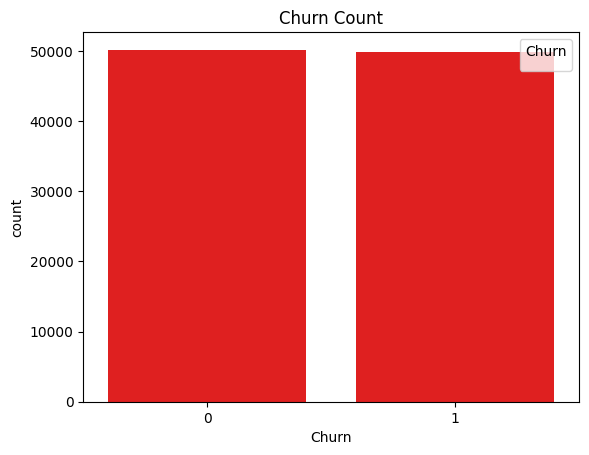

In [37]:
sns.countplot(x="Churn",
              data=df,
              color='red')
plt.title("Churn Count")
plt.legend(title="Churn")
plt.show()

# Pie chart

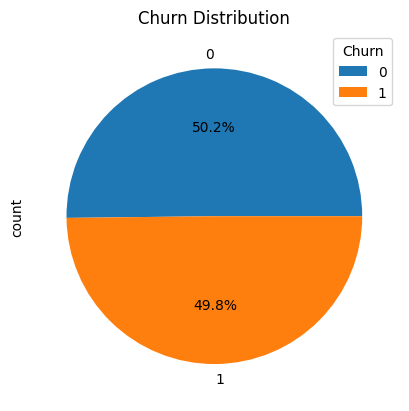

In [40]:
df["Churn"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Churn Distribution")
plt.legend(title="Churn")
plt.show()

# Histogram

/tmp/ipykernel_2474/3583276958.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Age")


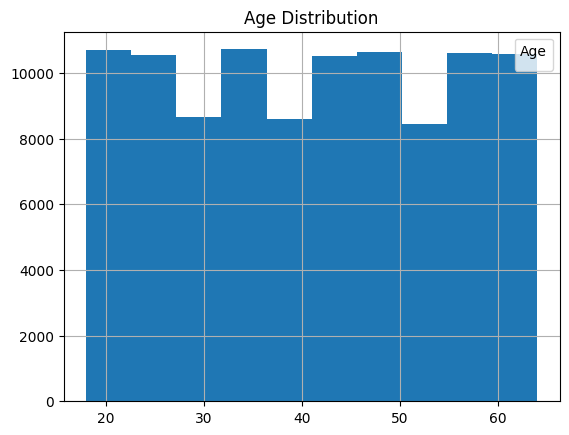

In [41]:
df["Age"].hist(),
color='red',
bins=10,
plt.title("Age Distribution")
plt.legend(title="Age")
plt.show()

# Scatter plot

/tmp/ipykernel_2474/2078156166.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


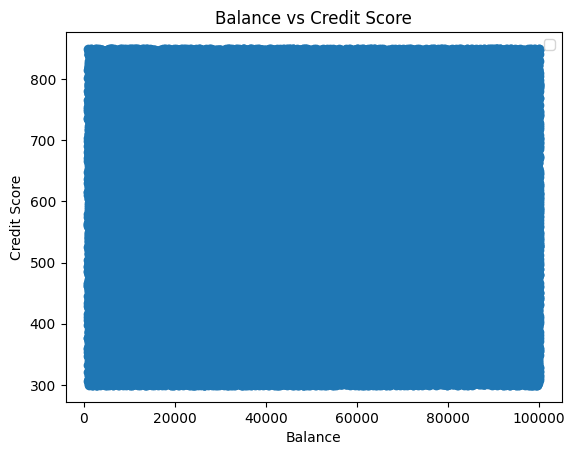

In [42]:
plt.scatter(df["Balance"], df["CreditScore"])
plt.xlabel("Balance")
plt.ylabel("Credit Score")
plt.title("Balance vs Credit Score")
plt.legend()
plt.show()

# Box plot

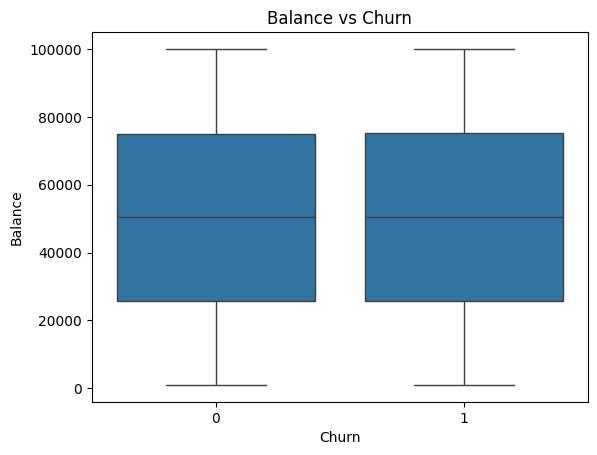

In [43]:
sns.boxplot(x="Churn", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()

# Heat map

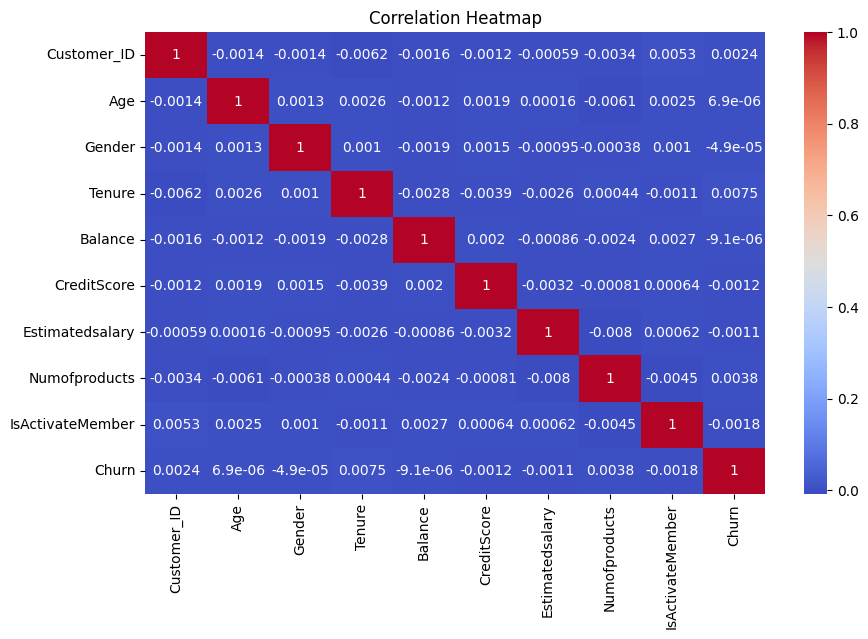

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Insights

In [46]:

high_risk = df[(df["Balance"] > 120000) & (df["IsActivateMember"] == 0)]
print("High Risk Customers:", len(high_risk))
low_credit = df[df["CreditScore"] < 500]
print("Low Credit Customers:", len(low_credit))

High Risk Customers: 0
Low Credit Customers: 36286
